In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import numpy as np
import os
import quantities as pq

import epych
from epych.signals import tfr
from epych.statistics import alignment, spectrum

[striatum:24421] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/972029952/shared_mem_cuda_pool.striatum could be created.
[striatum:24421] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0, pq.second)
ADAPTED_OFFSET = pq.Quantity(-0.5, pq.second)
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14, pq.second)
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676 * pq.second)
EVENTS = {
    "Adapted": (ADAPTED_ONSET.magnitude, 'lightgreen'),
    "Adapted Offset": (ADAPTED_OFFSET.magnitude, 'red'),
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
CONDITION_TITLES = {
    "lonaive": "Local Oddball Cue Trials",
    "go_gloexp": "Global Oddball",
    "go_seqctl": "AAAA Control",
    "lo_gloexp": "Local Oddball",
    "lo_rndctl": "AAAB Random",
    "igo_seqctl": "BBBB Control"
}

In [8]:
area_titles = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat):
    if name in area_titles:
        return area_titles[name]
    return name
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [9]:
def condition_stattitle(cond, name, stat):
    return stattitle(name, stat) + (" (%s)" % CONDITION_TITLES[cond])

In [10]:
def initialize_spectrum(key, signal, path=None):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0, chunk_trials=3, taper="hann", path=path + "/" + key)

In [11]:
FMIN, FMAX = pq.Quantity(0., pq.Hz), pq.Quantity(150., pq.Hz)

# Concatenating every trial of every condition would take hundreds of GB, and
# nothing below plots a single trial: accumulate trial sums one TFR file at a
# time instead, then divide by the trial counts.
TFR_SUMS, PSD_SUMS, TFR_META = {}, {}, {}
NTRIALS = collections.Counter()

In [12]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_spectrogram_downsample4_%s" % cond

    summary = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram)
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

    for area in anatomical_areas:
        for chunk in summary.stats[area].chunks():
            chunk = chunk.select_freqs(FMIN, FMAX)
            pows = chunk.data.magnitude.astype(np.float64)
            # Relative PSD, per trial, as power_spectrum().relative().evoked()
            # would take it: mean over time, then scale by the strongest channel.
            psds = pows.mean(axis=1)
            psds /= psds.max(axis=0, keepdims=True)

            if area in TFR_SUMS:
                assert np.allclose(chunk.times.magnitude,
                                   TFR_META[area][-1].magnitude,
                                   atol=chunk.dt.magnitude)
                TFR_SUMS[area] += pows.sum(axis=-1)
                PSD_SUMS[area] += psds.sum(axis=-1)
            else:
                TFR_SUMS[area], PSD_SUMS[area] = pows.sum(axis=-1), psds.sum(axis=-1)
                TFR_META[area] = (chunk.channels, chunk.df, chunk.dt, chunk.f0,
                                  chunk.freqs, chunk.times)
            NTRIALS[area] += pows.shape[-1]

            del pows, psds, chunk
        logging.info("Accumulated %d %s trials over conditions up to %s" %
                     (NTRIALS[area], area, cond))

    del summary

INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Accumulated 700 VISp trials over conditions up to lonaive
INFO:root:Accumulated 750 VISl trials over conditions up to lonaive
INFO:root:Accumulated 750 VISrl trials over conditions up to lonaive
INFO:root:Accumulated 550 VISal trials over conditions up to lonaive
INFO:root:Accumulated 700 VISpm trials over conditions up to lonaive
INFO:root:Accumulated 700 VISam trials over conditions up to lonaive
INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Accumulated 2741 VISp trials over conditions up to go_gloexp
INFO:root:Accumulated 2947 VISl trials over conditions up to go_gloexp
INFO:root:Accumulated 2936 VISrl trials over conditions up to go_gloexp
INFO:root:Accumulated 2145 VISal trials over conditions up to go_gloexp
INFO:root:Accumulated 2741 VISpm trials over conditions up to go_gloexp
INFO:root:Accumulated 2741 VISam trials over conditions up to go_gloexp
INFO:root:Loaded LFP spectrograms acro

In [13]:
tfrs = epych.recording.EvokedSampling(
    epych.recording.empty_intervals(), epych.recording.empty_trials(),
    epych.recording.default_units(),
    **{area: tfr.EvokedTfr(channels,
                           pq.Quantity(TFR_SUMS[area][..., np.newaxis] / NTRIALS[area],
                                       pq.mV ** 2 / pq.Hz),
                           df, dt, f0, freqs, times)
       for area, (channels, df, dt, f0, freqs, times) in TFR_META.items()}
)
psds = {
    area: spectrum.PowerSpectrum(df, channels, f0, fmax=freqs[-1], freqs=freqs,
                                 data=pq.Quantity(PSD_SUMS[area] / NTRIALS[area],
                                                  pq.dimensionless))
    for area, (channels, df, dt, f0, freqs, times) in TFR_META.items()
}

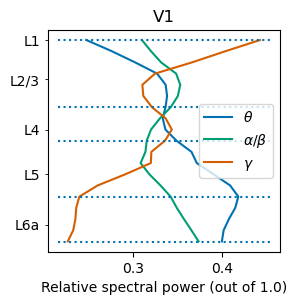

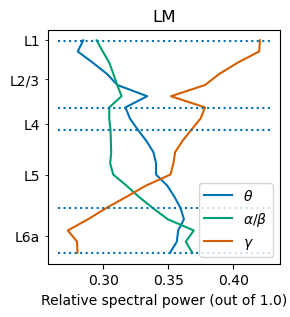

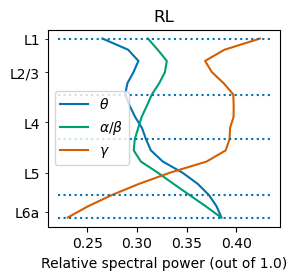

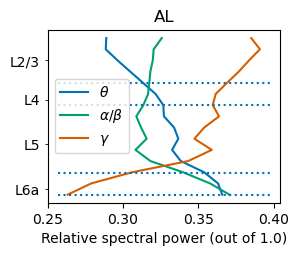

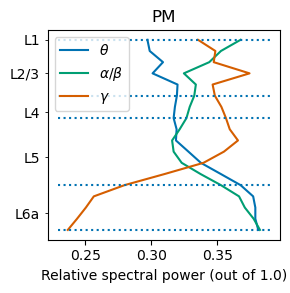

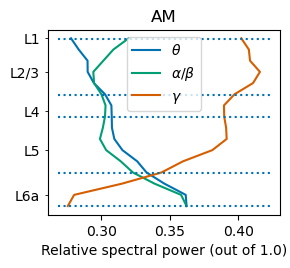

INFO:root:Plotted band powers over time across condition igo_seqctl


In [14]:
ALPHABETA_BAND = pq.Quantity([10, 19], pq.Hz)
GAMMA_BAND = pq.Quantity([75, 150], pq.Hz)

for area in anatomical_areas:
    os.makedirs("grand_spectrolaminar/", exist_ok=True)
    tfrs.signals[area].spectrolaminar_plot(filename="grand_spectrolaminar/%s.pdf" % (area),
                                           title=stattitle(area, tfrs.signals[area]), xlims=None,
                                           theta=(spectrum.THETA_BAND[0], spectrum.THETA_BAND[1], '$\\theta$'),
                                           alphabeta=(ALPHABETA_BAND[0], ALPHABETA_BAND[1], '$\\alpha / \\beta$'),
                                           gamma=(GAMMA_BAND[0], GAMMA_BAND[1], '$\\gamma$'))

logging.info("Plotted band powers over time across condition %s" % cond)

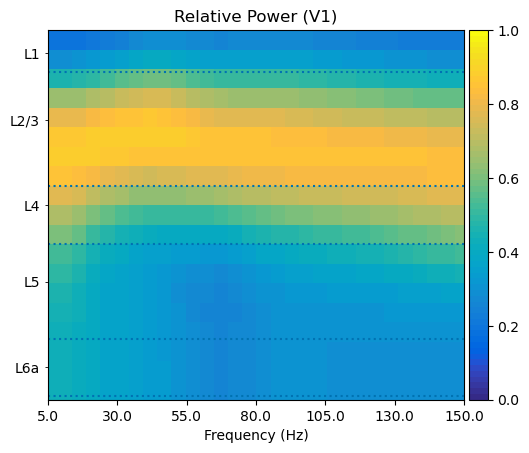

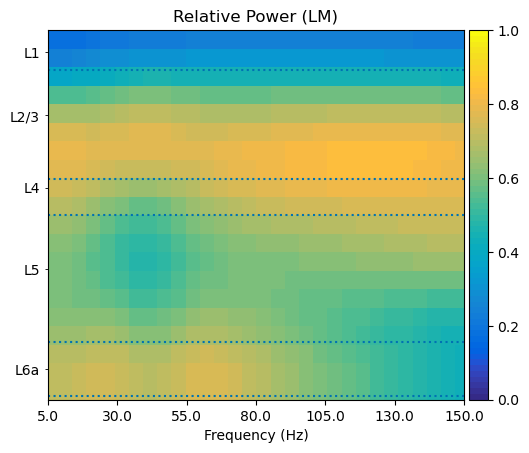

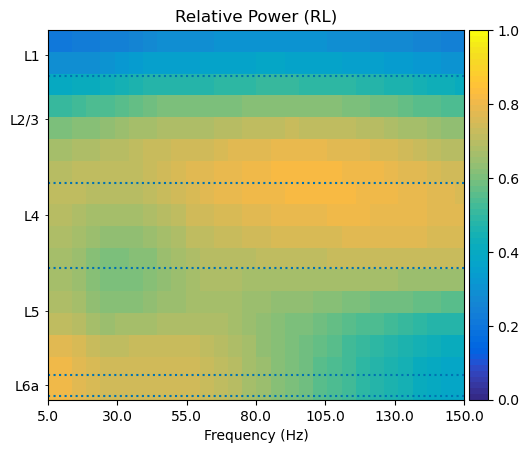

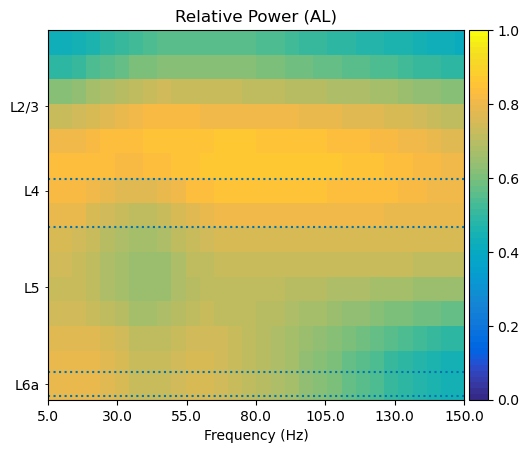

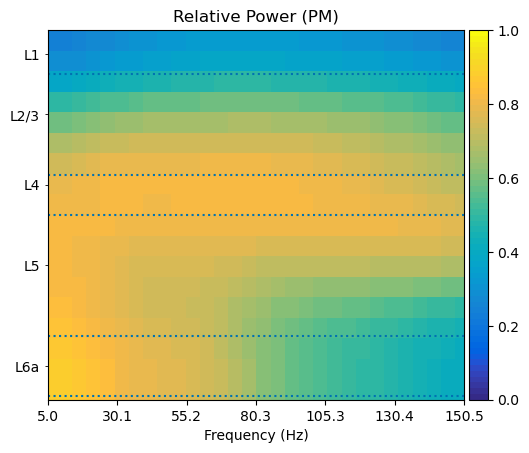

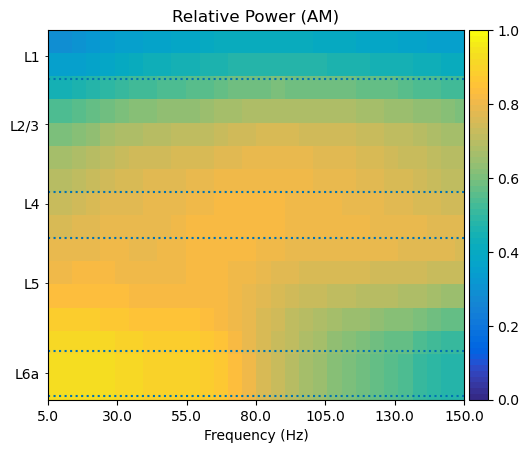

In [15]:
for area in anatomical_areas:
    os.makedirs("grand_spectrolaminar/", exist_ok=True)
    psds[area].heatmap(
        filename="grand_spectrolaminar/%s_psd.pdf" % area,
        subtitle=stattitle(area, tfrs.signals[area]), title="Relative Power",
        vmin=0., vmax=1.
    )